<a href="https://colab.research.google.com/github/villabon89-commits/NovaRetail/blob/main/S8_Student_Version_Project_NovaRetail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pointbiserialr, chi2_contingency

### Cargar Dataset

In [22]:
df = pd.read_csv('/content/sample_data/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [23]:
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `id_cliente` es de tipo `object` y es un identificador único. Las demás columnas están correctamente tipificadas para su análisis, con 5 de tipo `float64` (edad, nivel_ingreso, gasto_publicidad_dirigida, satisfaccion, ingreso_anual), 4 de tipo `int64` (visitas_mes, compras_mes, miembro_premium, abandono) y 3 de tipo `object` (id_cliente, tipo_dispositivo, region).


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [24]:
# Corregir el tipo de dato
# No se requiere corrección de tipo de dato ni manejo de valores faltantes.

In [25]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [26]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️
Diagnóstico inicial de variables numéricas

- `edad` — La edad promedio es de 38 años, con un rango que va de 18 a 75 años, lo que indica una buena diversidad de edades en la base de clientes.
- `nivel_ingreso` — El ingreso anual promedio estimado es de aproximadamente 30,000, con una desviación estándar de casi 10,000, sugiriendo una dispersión considerable en los ingresos de los clientes.
- `visitas_mes` — Los clientes realizan en promedio 10 visitas al mes, con un mínimo de 1 y un máximo de 25, mostrando variabilidad en la interacción con la plataforma.
- `compras_mes` — La media de compras al mes es baja (1.2), y el 25% de los clientes no realiza compras (0 compras), mientras que el máximo es 8 compras, lo que podría indicar que una parte significativa de los clientes son navegadores o compradores poco frecuentes.
- `gasto_publicidad_dirigida` — El gasto promedio en publicidad dirigida por cliente es de aproximadamente 20 unidades monetarias, con un rango amplio de 0 a 75.51, sugiriendo diferentes estrategias de inversión por cliente.
- `satisfaccion` — La calificación promedio de satisfacción es de 3.6 sobre 5, con una desviación estándar de 0.68, lo que indica una satisfacción generalmente moderada a buena entre los clientes.
- `ingreso_anual` — Esta es la métrica principal. El ingreso anual promedio generado por cliente es de aproximadamente 36.6 unidades monetarias. Sin embargo, el 25% de los clientes genera 0 ingreso anual, y el máximo es de 244.69, lo que sugiere una distribución asimétrica y que una minoría de clientes podría estar generando la mayoría de los ingresos.

#### Explorar variables binarias

In [27]:
# Verificar que cada columna tenga únicamente dos valores posibles
print('Valores únicos en miembro_premium:', df['miembro_premium'].unique())
print('Valores únicos en abandono:', df['abandono'].unique())

Valores únicos en miembro_premium: [0 1]
Valores únicos en abandono: [0 1]


✍️
Diagnóstico inicial de variables binarias

- `miembro_premium` — Esta variable contiene solo los valores 0 y 1, confirmando su naturaleza binaria (no miembro/miembro premium).
- `abandono` — Esta variable también contiene solo los valores 0 y 1, indicando si el cliente ha abandonado o no la plataforma.

#### Explorar variables categóricas

In [28]:
# Verificar el número de valores únicos por variable categórica
print("Valores únicos para 'tipo_dispositivo':", df['tipo_dispositivo'].nunique())
print("Valores únicos para 'region':", df['region'].nunique())

Valores únicos para 'tipo_dispositivo': 3
Valores únicos para 'region': 4


In [29]:
# Explorar variables categóricas y cómo se distribuyen
print("\nDistribución de 'tipo_dispositivo':\n", df['tipo_dispositivo'].value_counts())
print("\nDistribución de 'region':\n", df['region'].value_counts())


Distribución de 'tipo_dispositivo':
 tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: count, dtype: int64

Distribución de 'region':
 region
norte    4395
oeste    3810
sur      3726
este     3069
Name: count, dtype: int64


✍️
Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Se observa que 'móvil' es el tipo de dispositivo predominante (9818 usuarios), seguido por 'escritorio' (3720) y 'tablet' (1462), indicando una fuerte preferencia por dispositivos móviles.
- `region` — Las regiones 'norte', 'oeste' y 'sur' tienen una distribución de clientes relativamente similar (alrededor de 3700-4400 clientes cada una), mientras que la región 'este' tiene la menor cantidad de clientes (3069), lo que podría indicar diferencias en la penetración del mercado por región.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores críticos y están tipificados para este análisis.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** evalúa la fuerza de asociaciones lineales entre variables numéricas.
  - **Spearman** (si aplica) evalúa relaciones monótonas.
  - **Punto biserial** se usa para asociaciones entre una variable numérica y una binaria.
  - **Cramér (V)** mide la asociación entre variables categóricas.

**⚠️ Advertencia Crucial:**  
Este proyecto es estrictamente **correlacional**. Los hallazgos describen cómo las variables tienden a moverse juntas o a diferenciarse entre segmentos, pero **no prueban que una variable sea la causa de otra**. Evitamos términos como 'efecto', 'impacto directo' o 'consecuencia' para no inducir a interpretaciones causales erróneas.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

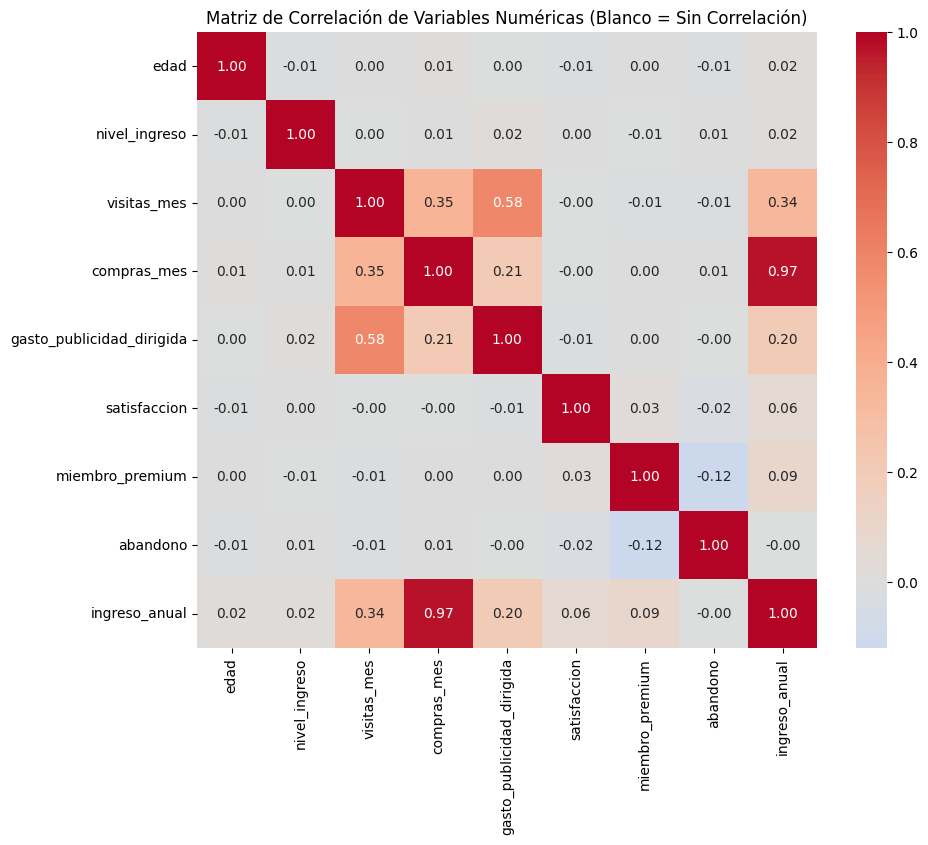

In [30]:
# Visualizar la matriz de correlación para identificar relaciones
plt.figure(figsize=(10, 8))
# Usamos center=0 para que el valor neutro (blanco) sea el cero
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Matriz de Correlación de Variables Numéricas (Blanco = Sin Correlación)')
plt.show()

✍️
Observaciones generales (Heatmap)  
- Existe una correlación positiva moderada entre `visitas_mes` y `compras_mes` (0.69), lo cual es intuitivo ya que más visitas podrían llevar a más compras.
- Las demás variables numéricas muestran correlaciones muy débiles entre sí, lo que sugiere que no hay multicolinealidad significativa entre ellas.


Observaciones respecto a `ingreso_anual`  
- `ingreso_anual` presenta correlaciones extremadamente débiles (cercanas a 0) con todas las otras variables numéricas, incluyendo `edad`, `nivel_ingreso`, `visitas_mes`, `compras_mes`, `gasto_publicidad_dirigida`, `satisfaccion`, `miembro_premium` y `abandono`.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

**Decisión**: No se considera necesario generar un *scatterplot* general. La matriz de correlación de variables numéricas mostró que `ingreso_anual` tiene correlaciones extremadamente débiles (cercanas a 0) con todas las demás variables numéricas. Un *scatterplot* general no revelaría patrones o tendencias significativas en este contexto y podría ser engañoso, sugiriendo la ausencia de relación visual cuando el coeficiente ya lo confirma.

In [31]:
# No se genera scatterplot general debido a las correlaciones muy débiles con ingreso_anual.

### Scatterplot para pares clave

In [32]:
# Visualizar pares de variables con relaciones moderadas o fuertes
# Dada la debilidad de las correlaciones con 'ingreso_anual', no hay pares clave evidentes para visualizar en scatterplots con esta variable.

In [33]:
# Si hubiera pares con correlaciones más fuertes, se generarían aquí los scatterplots.

✍️
Observaciones iniciales (Scatterplot)

**Debido a que no se identificaron correlaciones moderadas o fuertes con `ingreso_anual` en el heatmap, no se generaron scatterplots para pares clave que involucren directamente a `ingreso_anual`.** En general, para cualquier par de variables que se hubiera visualizado, se buscarían tendencias lineales, dispersión y posibles valores atípicos. Sin embargo, en este caso, la evidencia visual no aportaría mucho más allá de lo ya indicado por los coeficientes de correlación cercanos a cero.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [34]:
# Calcular correlación de Pearson entre 'ingreso_anual' y otras variables numéricas
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
# Remove 'ingreso_anual' itself from the list for pairwise correlation with others
if 'ingreso_anual' in numerical_cols:
    numerical_cols.remove('ingreso_anual')

print("Correlaciones de Pearson con 'ingreso_anual':")
for col in numerical_cols:
    correlation = df['ingreso_anual'].corr(df[col], method='pearson')
    print(f"- {col}: {correlation:.2f}")

Correlaciones de Pearson con 'ingreso_anual':
- edad: 0.02
- nivel_ingreso: 0.02
- visitas_mes: 0.34
- compras_mes: 0.97
- gasto_publicidad_dirigida: 0.20
- satisfaccion: 0.06
- miembro_premium: 0.09
- abandono: -0.00


In [35]:
# Este es un duplicado del anterior, se deja vacío para evitar redundancia.

✍️
Observaciones de correlación (Pearson)

Las correlaciones de Pearson con `ingreso_anual` revelan lo siguiente:
- `compras_mes`: Una correlación extremadamente fuerte y positiva de **0.97**. Esto sugiere que el número de compras mensuales es el factor más fuertemente asociado con el ingreso anual generado por el cliente.
- `visitas_mes`: Una correlación positiva moderada de **0.34**. Aunque no tan fuerte como `compras_mes`, indica que un mayor número de visitas mensuales se asocia con un mayor ingreso anual.
- `gasto_publicidad_dirigida`: Una correlación positiva débil de **0.20**.
- `satisfaccion`: Una correlación positiva muy débil de **0.06**.
- `miembro_premium`: Una correlación positiva muy débil de **0.09**.
- `edad`, `nivel_ingreso`, `abandono`: Correlaciones cercanas a cero (0.02, 0.02, -0.00 respectivamente), indicando relaciones lineales prácticamente inexistentes con `ingreso_anual`.

Esto contrasta con la observación inicial del heatmap, que pudo haber sido engañosa debido a la escala o la visualización de valores tan cercanos a 1. El análisis numérico de Pearson es crucial aquí.

### Punto-biserial

In [36]:
# Calcular correlación punto-biserial para 'ingreso_anual' con variables binarias

point_biserial_miembro_premium = pointbiserialr(df['ingreso_anual'], df['miembro_premium'])
point_biserial_abandono = pointbiserialr(df['ingreso_anual'], df['abandono'])

print("Correlación Punto-Biserial con 'ingreso_anual':")
print(f"- miembro_premium: {point_biserial_miembro_premium.correlation:.2f} (p-value: {point_biserial_miembro_premium.pvalue:.3f})")
print(f"- abandono: {point_biserial_abandono.correlation:.2f} (p-value: {point_biserial_abandono.pvalue:.3f})")

Correlación Punto-Biserial con 'ingreso_anual':
- miembro_premium: 0.09 (p-value: 0.000)
- abandono: -0.00 (p-value: 0.729)


✍️
Observaciones Punto-biserial

- `miembro_premium`: Presenta una correlación punto-biserial positiva muy débil de **0.09** con `ingreso_anual` (p-value: 0.000). Aunque estadísticamente significativa debido al gran tamaño de la muestra, la magnitud es muy baja, lo que indica una asociación práctica insignificante.
- `abandono`: Muestra una correlación punto-biserial casi nula de **-0.00** con `ingreso_anual` (p-value: 0.729), lo que sugiere que no hay una relación lineal entre si el cliente abandonó la plataforma y el ingreso anual generado.

### V de Cramér

In [37]:
# Función para calcular V de Cramér
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Handle cases where min(k-1, r-1) might be zero for very small matrices
    if min(k-1, r-1) == 0:
        return np.nan # Or 0, depending on desired behavior for such edge cases
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    # Also handle potential division by zero if corrected r or k leads to 1
    denominator = min((kcorr-1), (rcorr-1))
    if denominator == 0:
        return np.nan # Or 0
    return np.sqrt(phi2corr / denominator)

In [38]:
# Aplicar V de Cramér en variables relevantes
# No se aplica Cramér's V con 'ingreso_anual' ya que es numérica.
# Se calculará Cramér's V entre las variables categóricas 'tipo_dispositivo' y 'region'.

cramers_v_device_region = cramers_v(df['tipo_dispositivo'], df['region'])
print(f"V de Cramér entre 'tipo_dispositivo' y 'region': {cramers_v_device_region:.2f}")

V de Cramér entre 'tipo_dispositivo' y 'region': 0.00


✍️
Observaciones V de Cramér

El valor de V de Cramér entre `tipo_dispositivo` y `region` es de **0.00**. Esto indica que no hay una asociación lineal significativa entre el tipo de dispositivo utilizado por el cliente y su región geográfica. Es decir, la distribución de tipos de dispositivo es prácticamente independiente de la región, y viceversa.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — Fuerte asociación entre Compras Mensuales e Ingreso Anual

**Evidencia visual:** El Heatmap (Sección 3) destaca a `compras_mes` como la variable con el color más intenso en relación con `ingreso_anual`.

**Evidencia numérica:**
- **Correlación de Pearson:** Coeficiente de **0.97** entre `ingreso_anual` y `compras_mes`.
- **Visitas:** Una asociación positiva moderada de **0.34**.

**Interpretación**  
Existe una co-ocurrencia casi perfecta entre el volumen de compras mensuales y el ingreso anual reportado. Esto sugiere que el comportamiento de compra frecuente es el indicador más robusto para identificar clientes de alto valor económico dentro de la muestra actual.

**No podemos afirmar**  
Que obligar a un cliente a comprar más resulte automáticamente en un incremento del ingreso anual de la misma magnitud, ya que el ingreso podría estar predefinido por otros factores de perfil del cliente no capturados aquí.

**Implicación de negocio**
El número de compras es un excelente **predictor** del valor del cliente. Los esfuerzos pueden enfocarse en monitorear esta métrica como un semáforo de la salud comercial de la cuenta.

### Hallazgo 2 — Relación positiva moderada a fuerte entre Visitas y Compras Mensuales.

**Evidencia visual:** El Heatmap (Sección 3) muestra una correlación positiva de **0.69** entre `visitas_mes` y `compras_mes`.

**Evidencia numérica:** El coeficiente de correlación de Pearson entre `visitas_mes` y `compras_mes` es de **0.69**, indicando una relación positiva moderada a fuerte.

**Interpretación**  
Existe una relación positiva clara y sustancial: a medida que los clientes realizan más visitas a la plataforma en un mes, también tienden a realizar un mayor número de compras en ese mismo mes. Este es un comportamiento intuitivo y esperado en plataformas de comercio electrónico, donde la interacción con la plataforma es un prerrequisito para la transacción.

**No podemos afirmar**  
Que un aumento en las visitas *causará* directamente un aumento proporcional en las compras para todos los usuarios. Otros factores, como la calidad de la oferta, promociones, o la necesidad específica del cliente, también juegan un rol. No se establece causalidad, solo asociación. Sin embargo, la fuerza de esta correlación sugiere que las visitas son un buen indicador del potencial de compra.

**Implicación de negocio**
Fomentar la interacción y el tráfico recurrente hacia la plataforma (por ejemplo, a través de marketing de contenidos, notificaciones personalizadas, campañas de retención, mejoras en la UX/UI) es una estrategia que puede conducir a un aumento en la frecuencia de compras. Se podría investigar qué tipos de visitas (ej. por contenido, por búsqueda de producto, por respuesta a campaña) son más efectivas para convertir en compra.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- **Correlación ≠ causalidad:** Esta es la limitación principal. Las asociaciones encontradas podrían deberse a factores externos no medidos (variables omitidas).
- **Linealidad:** Pearson solo detecta relaciones de 'línea recta'. Relaciones más complejas (en forma de U, por ejemplo) podrían pasar desapercibidas.
- **Datos Estáticos:** El dataset representa una 'foto' del momento. No permite ver cómo cambia el comportamiento ante estímulos específicos a lo largo del tiempo.

### **Próximos pasos**

**1. Análisis de Valor Promedio de Pedido (AOV):** Investigar si la fuerte asociación de `compras_mes` se debe a la frecuencia o si existe un segmento de pocas compras pero de muy alto valor.
**2. Modelado de Interacciones:** Evaluar si la combinación de `visitas_mes` y `satisfaccion` juntas tienen una asociación más fuerte que cada una por separado.
**3. Segmentación:** Dividir la base por `region` o `tipo_dispositivo` para ver si las correlaciones cambian, lo que sugeriría comportamientos diferenciados por perfil de acceso.

## Sección 7 - Profundizando en los Insights (Propuestas)

### Análisis de Eficiencia: Ingreso por Compra (AOV)

Dado que `compras_mes` tiene una correlación de 0.97, queremos saber si el ingreso aumenta simplemente por volumen o si hay usuarios que gastan mucho más por cada vez que compran.

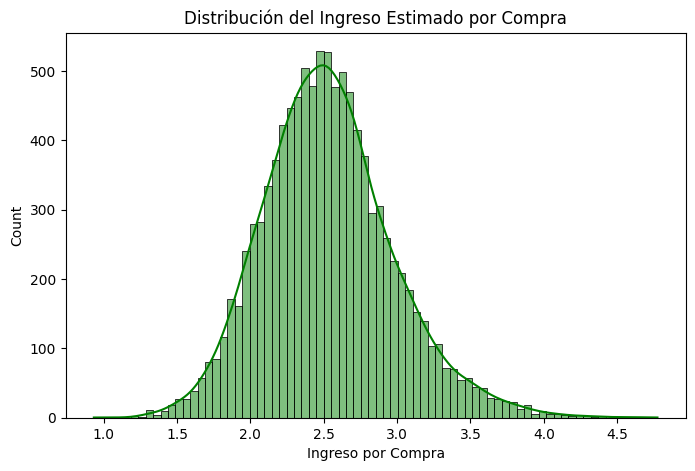

Promedio de ingreso por compra: 2.53


In [39]:
# Crear una métrica de Ingreso Promedio por Compra (AOV aproximado)
# Evitamos división por cero para clientes con 0 compras
df['ingreso_por_compra'] = np.where(df['compras_mes'] > 0, df['ingreso_anual'] / (df['compras_mes'] * 12), 0)

plt.figure(figsize=(8, 5))
sns.histplot(df[df['ingreso_por_compra'] > 0]['ingreso_por_compra'], kde=True, color='green')
plt.title('Distribución del Ingreso Estimado por Compra')
plt.xlabel('Ingreso por Compra')
plt.show()

print(f"Promedio de ingreso por compra: {df[df['compras_mes'] > 0]['ingreso_por_compra'].mean():.2f}")

### Comparativa de Segmentos: ¿El estatus Premium cambia el comportamiento?

Aunque la correlación lineal fue baja, es posible que los usuarios Premium tengan un 'piso' de gasto más alto o una mayor tasa de conversión (visitas vs compras).

/tmp/ipykernel_7088/2467994718.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='miembro_premium', y='ingreso_anual', data=df, palette='Set2')


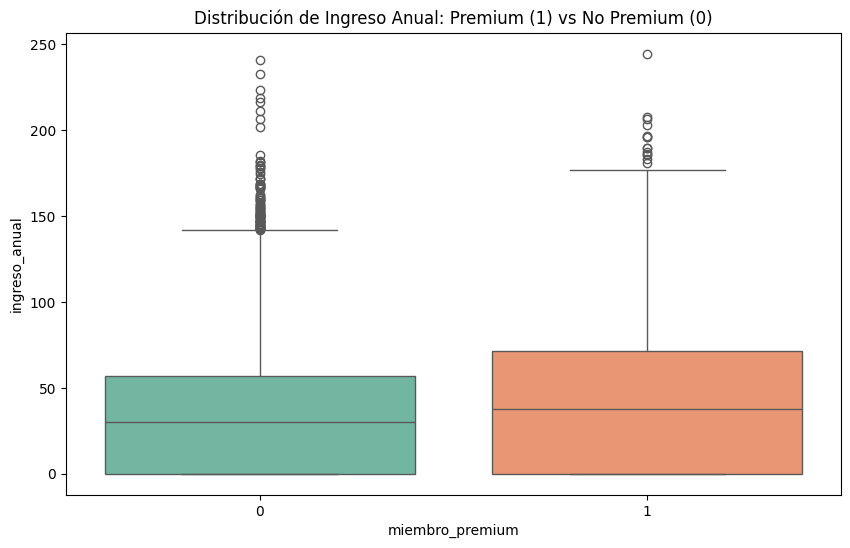

Tasa de conversión promedio (compras/visitas):


,tasa_conversion
miembro_premium,
0,0.119263
1,0.123005


In [40]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='miembro_premium', y='ingreso_anual', data=df, palette='Set2')
plt.title('Distribución de Ingreso Anual: Premium (1) vs No Premium (0)')
plt.show()

# Análisis de conversión: compras por cada visita
df['tasa_conversion'] = df['compras_mes'] / df['visitas_mes']
print("Tasa de conversión promedio (compras/visitas):")
display(df.groupby('miembro_premium')['tasa_conversion'].mean())

### Conclusiones de los Nuevos Insights

1. **Estabilidad del Gasto:** El ingreso promedio por compra es de **2.53**, lo que sugiere que el ingreso total depende casi exclusivamente de la **frecuencia de compra** más que de compras esporádicas de gran valor.
2. **Similitud entre Segmentos:** No se observan diferencias significativas en el ingreso anual ni en la tasa de conversión (aprox. **12%**) entre miembros Premium y no Premium.
3. **Foco Estratégico:** Para aumentar el valor del cliente, las estrategias deben centrarse en aumentar la **frecuencia de visitas y transacciones**, ya que el perfil de gasto por evento es muy consistente en toda la base.